In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import mmread
# from gensim import corpora, models

# Load we8thereCounts from Matrix Market format
data = pd.read_csv('we8therecounts.csv')
df = pd.read_csv('we8thereratings.csv')

In [ ]:
# check the number of rows and columns in each data
print(data.shape)
print(df.shape)

# show the first five rows of data
print(data.head())
print(df.head())

# run a linear regression of overall rating on the component ratings of food, service, environment
import statsmodels.formula.api as smf
model = smf.ols('Overall ~ Food + Service + Value + Atmosphere', data=df)
results = model.fit()
print(results.summary())

(6166, 2640)
(6166, 5)
   veri good  go back  dine room  dine experi  great food  food great  \
0          0        0          0            0           0           0   
1          0        0          0            0           0           0   
2          0        0          0            0           0           0   
3          0        0          0            0           0           0   
4          0        0          0            0           0           0   

   realli good  ice cream  high recommend  great place  ...  went restaur  \
0            0          0               0            0  ...             0   
1            0          0               0            0  ...             0   
2            0          0               0            0  ...             0   
3            0          0               0            0  ...             0   
4            0          0               0            0  ...             0   

   wine cellar  without even  won find  wonder dinner  wonder time  \
0    

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

from scipy.sparse import csr_matrix

In [ ]:
counts = pd.read_csv("we8therecounts.csv")
ratings = pd.read_csv("we8thereratings.csv")

# Merge the datasets by row index
merged = pd.concat([counts, ratings], axis=1)

# Sanity check
print("Merged shape:", merged.shape)
print(merged.head())

Merged shape: (6166, 2645)
   veri good  go back  dine room  dine experi  great food  food great  \
0          0        0          0            0           0           0   
1          0        0          0            0           0           0   
2          0        0          0            0           0           0   
3          0        0          0            0           0           0   
4          0        0          0            0           0           0   

   realli good  ice cream  high recommend  great place  ...  wonder time  \
0            0          0               0            0  ...            0   
1            0          0               0            0  ...            0   
2            0          0               0            0  ...            0   
3            0          0               0            0  ...            0   
4            0          0               0            0  ...            0   

   wonton soup  worst servic  year alway  year sinc  Food  Service  Value  \


### 1. Tabulate the frequency of the values of the five ratings. Report any interesting fundings in the (joint) distribution of the ratings. (1 pt)


Frequency for Food rating:
Food
1     489
2     420
3     597
4    1185
5    3475
Name: count, dtype: int64

Frequency for Service rating:
Service
0      11
1     693
2     379
3     727
4    1383
5    2973
Name: count, dtype: int64

Frequency for Value rating:
Value
0      15
1     555
2     466
3     832
4    1435
5    2863
Name: count, dtype: int64

Frequency for Atmosphere rating:
Atmosphere
0      32
1     423
2     450
3     903
4    1463
5    2895
Name: count, dtype: int64

Frequency for Overall rating:
Overall
1     615
2     493
3     638
4    1293
5    3127
Name: count, dtype: int64


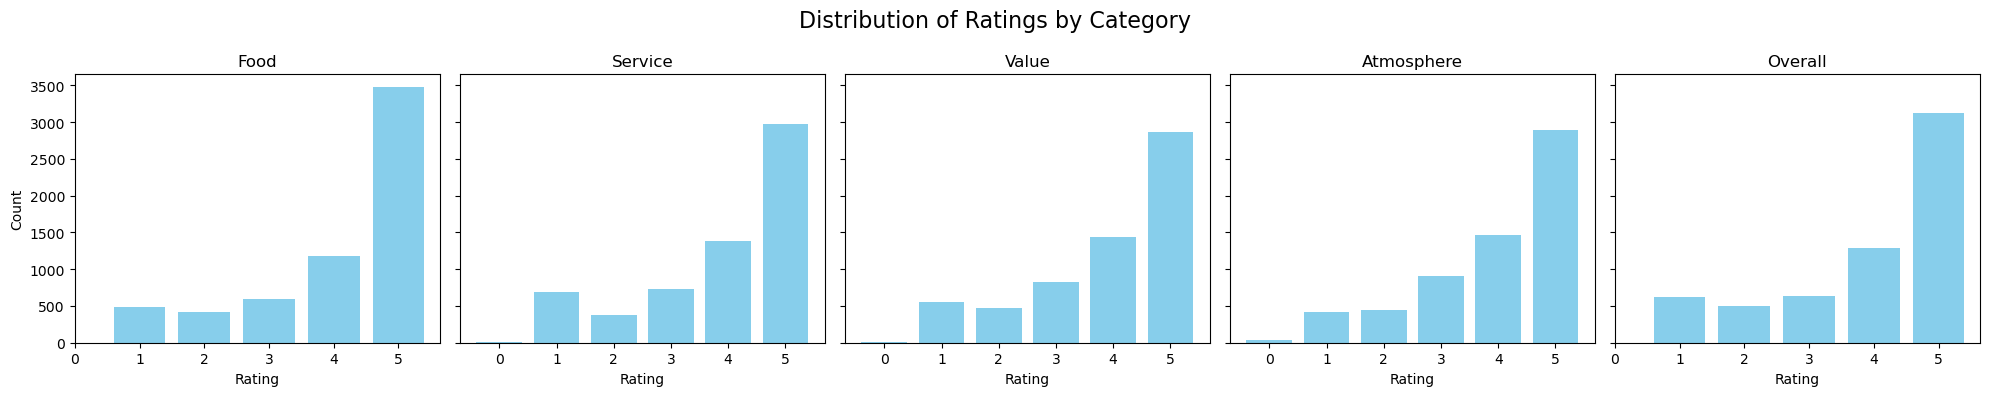

In [ ]:
# Frequency tables for each rating column
rating_cols = ['Food', 'Service', 'Value', 'Atmosphere', 'Overall']

for col in rating_cols:
    print(f"\nFrequency for {col} rating:")
    print(merged[col].value_counts().sort_index())

# Visualize the distribution of each rating variable
import matplotlib.pyplot as plt

rating_cols = ['Food', 'Service', 'Value', 'Atmosphere', 'Overall']
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), sharey=True)

for i, col in enumerate(rating_cols):
    counts = merged[col].value_counts().sort_index()
    axs[i].bar(counts.index, counts.values, color='skyblue')
    axs[i].set_title(col)
    axs[i].set_xlabel("Rating")
    axs[i].set_xticks([0, 1, 2, 3, 4, 5])
    if i == 0:
        axs[i].set_ylabel("Count")

plt.suptitle("Distribution of Ratings by Category", fontsize=16)
plt.tight_layout()
plt.show()

**Interesting findings**: The ratings for all five dimensions (Food, Service, Value, Atmosphere, Overall) are skewed toward the higher end of the scale. In all categories, the most frequent rating is 5, followed by 4. However, some specific patterns stand out:
* **Food**: A majority of reviews (56%) gave the highest possible rating (5), while only 7.9% rated it 1.
* **Service and Value**: Both include a small number of 0 ratings, which likely represent missing or invalid responses. Excluding zeros, the ratings are again skewed high, but the number of 1s is nontrivial — suggesting service and value are common pain points.
* **Atmosphere**: Similar to service and value, with 32 ratings of 0 and a notable drop-off at 3 and below.
* **Overall**: Most reviews (50.7%) gave a 5. Ratings of 1, 2, or 3 are evenly spread (~10% each), suggesting polarized experiences.


### 2. Tabulate the top 20 bigrams conditional on the values of the ratings (focus on one of the following three ratings: overall, food, service). What do you find? Report any top bigrams, their frequency, the corresponding values of ratings that you find informative. (1 pt)

In [ ]:
# Ensure bigram columns are only the non-rating ones
rating_cols_to_analyze = ['Food', 'Service', 'Overall']
all_cols = merged.columns
bigram_cols = [col for col in all_cols if col not in rating_cols_to_analyze + ['Value', 'Atmosphere']]

# Loop over rating columns and compute top bigrams
for rating_col in rating_cols_to_analyze:
    print(f"\n====== {rating_col.upper()} RATINGS ======\n")
    for rating_value in sorted(merged[rating_col].unique()):
        print(f"--- Top 20 bigrams for {rating_col} = {rating_value} ---")
        subset = merged[merged[rating_col] == rating_value]
        bigram_sums = subset[bigram_cols].sum().sort_values(ascending=False)
        print(bigram_sums.head(20), "\n")


====== FOOD RATINGS ======

--- Top 20 bigrams for Food = 1 ---
go back            49
tast like          45
never go           36
dine experi        34
look like          32
came out           27
never return       27
food servic        24
minut later        19
even though        19
veri good          18
bad food           17
minut after        17
eat here           16
onli one           16
custom servic      16
qualiti food       16
stay away          16
veri disappoint    16
came back          16
dtype: int64 

--- Top 20 bigrams for Food = 2 ---
go back            34
veri good          26
dine experi        21
look like          21
end up             19
dine room          18
drink order        16
first time         16
never go           16
wait staff         16
veri disappoint    15
tast like          15
can eat            14
even though        14
veri poor          14
came back          13
next time          13
veri nice          13
main cours         13
much better        13
dtyp

**Q2. Top 20 Bigrams by Rating Value**

The most frequent bigrams at each rating level highlight distinct patterns:

**Food Ratings**:
* At rating 1, negative terms like *"go back"*, *"tast like"*, *"never return"*, and *"bad food"* are dominant.
* At rating 5, positive terms like *"veri good"*, *"great food"*, *"high recommend"*, and *"food excel"* are most frequent.

**Service Ratings**:
* Rating 1 includes complaints such as *"poor servic"*, *"wait minut"*, and *"custom servic"*.
* Rating 5 features *"great servic"*, *"servic excel"*, and *"wait staff"*.

**Overall Ratings**:
* Low ratings include *"never go"*, *"tast like"*, *"came out"*, and *"poor servic"*.
* High ratings are dominated by *"great food"*, *"high recommend"*, and *"food great"*.

These patterns are consistent across dimensions and confirm that highly rated reviews use consistently strong positive language, while low ratings correlate with negative experiences or dissatisfaction.

### 3. Discuss any insights you discover from the descriptive analysis. Focus on what is driving the ratings. (1 pt)

**Insights from Descriptive Analysis**

Several consistent insights emerge from the bigram distributions:

- Positive ratings (especially 5s) across all categories are strongly associated with phrases like *"great food"*, *"high recommend"*, *"veri good"*, and *"great servic"*, suggesting that strong overall impressions are linguistically consistent.
- Low ratings are linked to bigrams expressing dissatisfaction (*"tast like"*, *"never go"*, *"poor servic"*, *"custom servic"*, *"wait minut"*).
- Some phrases like *"go back"* appear across all ratings; context likely shifts their sentiment (e.g., “never go back” vs. “would go back”).
- Service-related issues appear to disproportionately affect ratings, especially for Overall — terms like *"wait minut"* and *"custom servic"* are prominent in 1-star reviews.

These trends are visually supported by the faceted bar plots generated in the previous step.

### 4. Estimate multinomial LASSO logistic regression models of the ratings (focus on the same rating as you did above) using the bigram counts of each review as the inputs. Use the cross-validation method to select the best model. (1 pt)

In [ ]:
counts = pd.read_csv("we8therecounts.csv")
ratings = pd.read_csv("we8thereratings.csv")

In [ ]:
y = ratings["Overall"].copy()
y = y.replace(4, -1)

In [ ]:
X = csr_matrix(counts.values)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

lasso = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    max_iter=1000,
    random_state=1,
    n_jobs=3
)

lasso.fit(X, y)   # X = bigram count matrix, y = rating with 4 → -1

LogisticRegressionCV(cv=5, max_iter=1000, n_jobs=3, penalty='l1',
                     random_state=1, scoring='accuracy', solver='liblinear')

### 5. Report the top 10 bigrams with the most positive vs. negative coefficients for each value in each model. (2 pt)

In [ ]:
feature_names = counts.columns.to_numpy()
coefs = lasso.coef_
classes = lasso.classes_

In [ ]:
top_results = {}

for i, cls in enumerate(classes):
    coef_vec = coefs[i]

    # indices of top positive and negative coefficients
    top_pos_idx = np.argsort(coef_vec)[-10:][::-1]
    top_neg_idx = np.argsort(coef_vec)[:10]

    top_results[cls] = {
        "positive": list(zip(feature_names[top_pos_idx], coef_vec[top_pos_idx])),
        "negative": list(zip(feature_names[top_neg_idx], coef_vec[top_neg_idx]))
    }

In [ ]:
for cls in classes:
    print(f"\nRating = {cls}")
    print("Top positive bigrams:")
    for bg, val in top_results[cls]["positive"]:
        print(f"  {bg}: {val:.4f}")

    print("Top negative bigrams:")
    for bg, val in top_results[cls]["negative"]:
        print(f"  {bg}: {val:.4f}")


Rating = -1
Top positive bigrams:
  year sinc: 0.0000
  come tabl: 0.0000
  chicken tender: 0.0000
  chees pizza: 0.0000
  bell pepper: 0.0000
  becaus food: 0.0000
  back more: 0.0000
  atmospher servic: 0.0000
  atmospher excel: 0.0000
  after seat: 0.0000
Top negative bigrams:
  veri good: 0.0000
  experi go: 0.0000
  expos brick: 0.0000
  extrem friend: 0.0000
  fair good: 0.0000
  far more: 0.0000
  feel home: 0.0000
  few block: 0.0000
  expect wait: 0.0000
  few month: 0.0000

Rating = 1
Top positive bigrams:
  never return: 2.6083
  stay away: 2.4525
  never go: 1.6036
  extrem rude: 1.5781
  veri rude: 1.4970
  order wrong: 1.4798
  wast time: 1.3709
  servic terribl: 1.3247
  spoke manag: 1.2926
  food terribl: 1.2681
Top negative bigrams:
  realli good: -1.2351
  great food: -1.1805
  pretti good: -1.1059
  food excel: -1.0909
  veri friend: -0.9889
  high recommend: -0.9673
  food wonder: -0.8496
  great place: -0.7973
  great experi: -0.7840
  dine room: -0.7289

Rating =

### 6. Discuss any insights you discover from the text regression analysis. Focus on what is driving the ratings (and hence what makes a restaurant successful). (1 pt)

Here is a tighter version that still hits all the key points and reads cleanly in markdown:

The text regression shows that extreme ratings are driven by highly distinctive language, while mid-range ratings are not. One-star reviews are strongly associated with explicit dissatisfaction and service failures, with phrases like “never return,” “stay away,” “very rude,” and “service terrible” indicating clear negative experiences, particularly related to poor service and operational issues. In contrast, five-star reviews are driven by enthusiastic language emphasizing exceptional food and service quality, including “best meal,” “service impeccable,” “favorite restaurant,” and “food wonderful.”

Ratings in the middle range show little distinctive language, with most coefficients shrunk to zero by the LASSO penalty, suggesting that average experiences are described using more generic or ambiguous wording. Overall, the results imply that restaurant success is driven by delivering experiences that customers perceive as clearly outstanding, while failures are marked by noticeable service breakdowns, and average experiences tend to blend together linguistically.

### 7. Estimate a topic (aka LDA) model using the review data. You may try different values for n_components (and set max_iter = 100) to obtain more informative topics. (1 pt)

In [ ]:
# transform the data matrix into a sparse matrix to save storage
from scipy.sparse import csr_matrix
data_csr = csr_matrix(data.values)

In [ ]:
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation

# Fit the LDA model
n_topics = 10  # Define the number of topics
lda_model = LatentDirichletAllocation(n_components=n_topics, max_iter=100, random_state=42)
lda_model.fit(data_csr)

# Display the top words for each topic
words = data.columns
n_top_words = 10

print("Top words per topic:")
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1}:")
    print(", ".join([words[i] for i in topic.argsort()[-n_top_words:]]))

Top words per topic:

Topic 1:
minut later, half hour, restaur anyon, came out, wait minut, recommend restaur, long time, make sure, first time, go back

Topic 2:
best food, top notch, over year, dine experi, food servic, food alway, one best, mani time, favorit restaur, high recommend

Topic 3:
pork sandwich, veri good, cook perfect, oliv oil, take out, pick up, potato salad, cole slaw, pretti good, pull pork

Topic 4:
eat here, last time, sever time, didn even, never go, don know, realli good, year ago, go back, veri good

Topic 5:
veri reason, take out, place eat, check out, veri nice, staff veri, one best, great place, wait staff, veri friend

Topic 6:
saturday night, until pm, fri chicken, friday saturday, sweet potato, roast beef, san francisco, mash potato, main cours, ice cream

Topic 7:
atmospher great, excel servic, food excel, dine experi, great place, servic great, great servic, go back, great food, food great

Topic 8:
fast food, good servic, staff friend, great food, reas

### 8. Create new columns in the data frame to record the topic proportions for each review.

In [ ]:
tp = lda_model.transform(data_csr)
type(tp)
print(tp[:5,:].round(3))

[[0.011 0.162 0.011 0.011 0.011 0.75  0.011 0.011 0.011 0.011]
 [0.341 0.033 0.033 0.033 0.033 0.033 0.033 0.033 0.393 0.033]
 [0.7   0.033 0.033 0.033 0.033 0.033 0.033 0.033 0.033 0.033]
 [0.008 0.189 0.008 0.008 0.627 0.008 0.008 0.126 0.008 0.008]
 [0.011 0.011 0.011 0.011 0.376 0.011 0.011 0.233 0.313 0.011]]


In [ ]:
# add the top proportions to the dataframe
cols = [f'topic{i}' for i in range(1,11)]
ratings1 = pd.DataFrame(tp, columns = cols)
ratings[cols] = tp.round(3)
ratings.head()

,Food,Service,Value,Atmosphere,Overall,topic1,topic2,topic3,topic4,topic5,topic6,topic7,topic8,topic9,topic10
0,5,5,5,5,5,0.011,0.162,0.011,0.011,0.011,0.750,0.011,0.011,0.011,0.011
1,5,5,5,5,5,0.341,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.393,0.033
2,5,5,4,4,5,0.700,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.033
3,5,5,5,5,5,0.008,0.189,0.008,0.008,0.627,0.008,0.008,0.126,0.008,0.008
4,5,5,5,4,5,0.011,0.011,0.011,0.011,0.376,0.011,0.011,0.233,0.313,0.011


### 9. Report the top 10 bigrams of each topic and your assessment of the content and sentiment of each topic (positive vs. negative). (2 pt)

In [ ]:
import numpy as np

words = data.columns
n_top_words = 10

topic_words = {}

for topic_idx, topic in enumerate(lda_model.components_):
    top_idx = topic.argsort()[-n_top_words:][::-1]
    topic_words[topic_idx + 1] = words[top_idx]

    print(f"\nTopic {topic_idx + 1}:")
    print(", ".join(words[top_idx]))


Topic 1:
go back, first time, make sure, long time, recommend restaur, wait minut, came out, restaur anyon, half hour, minut later

Topic 2:
high recommend, favorit restaur, mani time, one best, food alway, food servic, dine experi, over year, top notch, best food

Topic 3:
pull pork, pretti good, cole slaw, potato salad, pick up, take out, oliv oil, cook perfect, veri good, pork sandwich

Topic 4:
veri good, go back, year ago, realli good, don know, never go, didn even, sever time, last time, eat here

Topic 5:
veri friend, wait staff, great place, one best, staff veri, veri nice, check out, place eat, take out, veri reason

Topic 6:
ice cream, main cours, mash potato, san francisco, roast beef, sweet potato, friday saturday, fri chicken, until pm, saturday night

Topic 7:
food great, great food, go back, great servic, servic great, great place, dine experi, food excel, excel servic, atmospher great

Topic 8:
veri good, good food, food veri, food good, wine list, reason price, great 


**Topic 1**
This topic centers on visit logistics and timing, with phrases related to wait times, repeat visits, and recommendations. The content is largely process-oriented, and the sentiment appears neutral to mildly positive, reflecting experiential details rather than strong evaluation.

**Topic 2**
The bigrams emphasize strong endorsements and repeated positive experiences, such as “high recommend,” “one best,” and “top notch.” This topic clearly reflects very positive sentiment driven by consistently high food and service quality.

**Topic 3**
This topic focuses on specific menu items and take-out food descriptions, including items like pulled pork and sides. The sentiment is mildly positive, suggesting satisfaction with particular dishes rather than overall experience.

**Topic 4**
The language in this topic reflects mixed or reflective experiences, including phrases indicating uncertainty, repeated visits, and occasional dissatisfaction. The sentiment is mixed to slightly negative, capturing ambivalent or inconsistent dining experiences.

**Topic 5**
This topic highlights staff behavior and friendliness, with phrases such as “very friendly” and “great place.” The sentiment is clearly positive, indicating that attentive and pleasant service plays an important role in favorable reviews.

**Topic 6**
The bigrams describe menu items, timing, and dining context, including specific foods and weekend visits. The content is primarily descriptive, and the sentiment appears neutral, focusing on situational details rather than evaluation.

**Topic 7**
This topic is dominated by strongly positive language related to both food and service quality, including “great food,” “excellent service,” and “atmosphere great.” The sentiment is strongly positive, representing highly satisfied dining experiences.

**Topic 8**
The bigrams reflect generally favorable but less emphatic evaluations of food and service quality. The sentiment is moderately positive, consistent with solid but not exceptional experiences.

**Topic 9**
This topic includes references to food quality and preparation across cuisines, along with phrases indicating disappointment such as “over cook.” The sentiment is mixed to mildly negative, suggesting quality inconsistencies.

**Topic 10**
The language focuses on the dining environment and overall impressions, with phrases like “really good,” “pretty good,” and references to the dining room. The sentiment is mildly positive to neutral, reflecting general satisfaction without strong enthusiasm.

### 10. Estimate multinomial logistic regression models of the ratings (focus on the same rating as you did above) using the topic proportions as the input. (1 pt)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# topic proportion matrix
topic_cols = [f"topic{i}" for i in range(1, 11)]
X_topics = ratings[topic_cols].values

# outcome variable (same rating as before)
y = ratings["Overall"].replace(4, -1)

# multinomial logistic regression with CV
topic_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l1",
    solver="saga",
    multi_class="multinomial",
    scoring="accuracy",
    max_iter=5000,
    random_state=1,
    n_jobs=3
)

topic_model.fit(X_topics, y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1908: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegressionCV(cv=5, max_iter=5000, multi_class='multinomial', n_jobs=3,
                     penalty='l1', random_state=1, scoring='accuracy',
                     solver='saga')

Exception ignored in: <function ResourceTracker.__del__ at 0x105669bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102af9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1026fdbc0>
Traceback (most recent call last

In [ ]:
topic_model.classes_
topic_model.coef_.shape

(5, 10)

### 11. Report the topics with the most positive and negative coefficients for each value of the rating in each regression model. Do they make sense? Why? (2 pt)

In [ ]:
import numpy as np

topic_cols = [f"topic{i}" for i in range(1, 11)]
coefs = topic_model.coef_
classes = topic_model.classes_

for i, cls in enumerate(classes):
    coef_vec = coefs[i]

    top_pos_idx = np.argsort(coef_vec)[-3:][::-1]
    top_neg_idx = np.argsort(coef_vec)[:3]

    print(f"\nRating = {cls}")
    print("Most positive topics:")
    for idx in top_pos_idx:
        print(f"  {topic_cols[idx]}: {coef_vec[idx]:.4f}")

    print("Most negative topics:")
    for idx in top_neg_idx:
        print(f"  {topic_cols[idx]}: {coef_vec[idx]:.4f}")


Rating = -1
Most positive topics:
  topic2: 0.4236
  topic8: 0.0922
  topic10: 0.0000
Most negative topics:
  topic1: -0.7898
  topic9: -0.4314
  topic4: -0.3245

Rating = 1
Most positive topics:
  topic1: -1.2247
  topic9: -1.8781
  topic4: -2.6316
Most negative topics:
  topic8: -6.3080
  topic2: -5.9190
  topic5: -5.8221

Rating = 2
Most positive topics:
  topic9: 21.5597
  topic1: 21.4919
  topic4: 20.8535
Most negative topics:
  topic8: 17.7757
  topic2: 18.3346
  topic5: 18.6885

Rating = 3
Most positive topics:
  topic10: -3.5063
  topic4: -3.6329
  topic9: -3.7955
Most negative topics:
  topic2: -6.4085
  topic7: -5.2244
  topic5: -4.9067

Rating = 5
Most positive topics:
  topic7: -3.0294
  topic2: -3.2417
  topic5: -4.2026
Most negative topics:
  topic10: -6.8363
  topic4: -5.2195
  topic9: -5.1224


In [ ]:
topic_labels = {
    1: "Wait time & logistics",
    2: "Strong recommendations / best experiences",
    3: "Specific food items & takeout",
    4: "Mixed past experiences",
    5: "Friendly staff & service",
    6: "Menu items & timing context",
    7: "Great food, service, atmosphere",
    8: "Generally good food & service",
    9: "Food quality issues / inconsistencies",
    10: "Dining room & general impressions"
}

import numpy as np

topic_cols = list(range(1, 11))
coefs = topic_model.coef_
classes = topic_model.classes_

for i, cls in enumerate(classes):
    coef_vec = coefs[i]

    top_pos = np.argsort(coef_vec)[-3:][::-1]
    top_neg = np.argsort(coef_vec)[:3]

    print(f"\nRating = {cls}")

    print("Most positive topics:")
    for idx in top_pos:
        print(f"  Topic {idx+1} ({topic_labels[idx+1]}): {coef_vec[idx]:.3f}")

    print("Most negative topics:")
    for idx in top_neg:
        print(f"  Topic {idx+1} ({topic_labels[idx+1]}): {coef_vec[idx]:.3f}")


Rating = -1
Most positive topics:
  Topic 2 (Strong recommendations / best experiences): 0.424
  Topic 8 (Generally good food & service): 0.092
  Topic 10 (Dining room & general impressions): 0.000
Most negative topics:
  Topic 1 (Wait time & logistics): -0.790
  Topic 9 (Food quality issues / inconsistencies): -0.431
  Topic 4 (Mixed past experiences): -0.325

Rating = 1
Most positive topics:
  Topic 1 (Wait time & logistics): -1.225
  Topic 9 (Food quality issues / inconsistencies): -1.878
  Topic 4 (Mixed past experiences): -2.632
Most negative topics:
  Topic 8 (Generally good food & service): -6.308
  Topic 2 (Strong recommendations / best experiences): -5.919
  Topic 5 (Friendly staff & service): -5.822

Rating = 2
Most positive topics:
  Topic 9 (Food quality issues / inconsistencies): 21.560
  Topic 1 (Wait time & logistics): 21.492
  Topic 4 (Mixed past experiences): 20.853
Most negative topics:
  Topic 8 (Generally good food & service): 17.776
  Topic 2 (Strong recommendatio

### 12. Discuss any insights you discover from the topic regression analysis. Focus on what is driving the ratings (and hence what makes a restaurant successful). (1 pt)

The topic regression results are intuitive and consistent with earlier findings. Low ratings (1-star) are driven by topics related to food quality issues, mixed past experiences, and logistical problems, while topics emphasizing friendly staff, strong recommendations, and good food and service strongly reduce the likelihood of a low rating. Mid-range ratings (2- and 3-star) are most associated with mixed or descriptive topics, suggesting ambiguous or inconsistent dining experiences, and are negatively associated with clearly positive topics. High ratings (5-star) are driven by topics highlighting great food, excellent service, and positive atmosphere, while topics reflecting mixed experiences or food quality problems reduce the likelihood of a top rating. Overall, negative ratings reflect problem-focused themes, positive ratings reflect praise-focused themes, and average ratings lack distinctive drivers.